<a href="https://colab.research.google.com/github/NaghamZidiah/FlyRank-ML-Internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

### Research question

Can observed search-performance signals be used to group content-page observations into clear performance archetypes that support content review and prioritization?

### Decision supported

The analysis is intended to help a content team identify broad groups of pages with similar observed search-performance patterns and decide where further editorial review may be useful.

The output is not an automated content decision. It is a directional, decision-support analysis that helps organize observations into broader performance archetypes.

### Lane

This capstone uses the **Structured Content Archetype Clustering** lane.

The task is unsupervised clustering because there is no predefined target label for the content archetypes. The clusters are discovered from observed search-performance features and then interpreted using their cluster profiles.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [ ]:
import duckdb
import pandas as pd
from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")
print("Token loaded successfully!")

con = duckdb.connect()

con.execute(f"""
CREATE SECRET hf_secret (
    TYPE HUGGINGFACE,
    TOKEN '{HF_TOKEN}'
)
""")

print("Connected successfully!")

rel = "hf://datasets/FlyRank/internship-warehouse"

Token loaded successfully!
Connected successfully!


In [ ]:
# Build a reproducible 100,000-row sample across March 2026
# using a deterministic hash-based selection.

capstone_query = f"""
SELECT
    report_date,
    client_hash_id,
    content_hash_id,
    gsc_impressions,
    gsc_clicks,
    gsc_avg_position
FROM read_parquet(
    '{rel}/fact_content_daily_performance/**/*.parquet'
)
WHERE month = '2026-03'
  AND gsc_impressions IS NOT NULL
  AND gsc_clicks IS NOT NULL
  AND gsc_avg_position IS NOT NULL
  AND gsc_impressions > 0
ORDER BY hash(content_hash_id || CAST(report_date AS VARCHAR))
LIMIT 100000
"""

capstone_df = con.sql(capstone_query).df()

print("Capstone sample size:", len(capstone_df))
print(
    "Date range:",
    capstone_df["report_date"].min(),
    "to",
    capstone_df["report_date"].max()
)

display(capstone_df.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Capstone sample size: 100000
Date range: 2026-03-01 00:00:00 to 2026-03-31 00:00:00


,report_date,client_hash_id,content_hash_id,gsc_impressions,gsc_clicks,gsc_avg_position
0,2026-03-24,client_23a62021009f63c4,content_d506a42ce73085b4,139,0,19.050360
1,2026-03-20,client_62f4a7e64f5e0096,content_3aad0b30802a8dc8,2,0,0.000000
2,2026-03-19,client_73cda7b4e4f265ea,content_9fbac1b1367ec8fc,33,0,5.333333
3,2026-03-03,client_23a62021009f63c4,content_41a2665e0a0755de,1,0,69.000000
4,2026-03-29,client_08a6a72ff48e62c0,content_0a40c858386aa8db,3,0,84.333333


### Data used

The analysis uses the March 2026 release of the FlyRank internship warehouse, specifically the `fact_content_daily_performance` table.

The working sample contains 100,000 observations from March 2026. Each observation represents a content-page performance record for a reporting date.

The analysis uses GSC impressions, GSC clicks, and GSC average position as the core performance signals.

Client and content identifiers are retained only for record tracking and grouping where needed. They are not used as model features.

Label-derived fields such as `trend_direction` and `trend_pct`, as well as product decision fields and other fields that could introduce leakage, are excluded from the clustering features.

No client names, domains, private queries, credentials, or raw private exports are included in the analysis or report.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

This capstone uses the Structured Content Archetype Clustering lane and treats the task as unsupervised clustering.

The analysis assumes that recurring combinations of search-performance signals can be summarized into interpretable content archetypes. No predefined target label is used.

### Features

The final clustering features are:

- `log_impressions`
- `log_clicks`
- `gsc_avg_position`

Log transformations are used for impressions and clicks because these fields are strongly right-skewed. Average search position is kept as a direct performance signal.

Client and content identifiers are not used as model features. Label-derived fields such as `trend_direction` and `trend_pct` are also excluded to avoid leakage.

### Baseline

The baseline is a transparent K-Means clustering approach using the raw search-performance features:

- `gsc_impressions`
- `gsc_clicks`
- `gsc_avg_position`

The baseline uses `k=3`.

### Model

The ML-08 model uses K-Means with the transformed feature set:

- `log_impressions`
- `log_clicks`
- `gsc_avg_position`

For a fair comparison, the model is evaluated using the same data sample, validation design, and silhouette metric as the baseline.

### Validation

The main validation design is time-aware. Earlier March observations are used for training and later March observations are held out for testing.

This is more realistic for evaluating whether the discovered clusters remain useful on later observations rather than only on a random split.

### Metric

The main evaluation metric is the silhouette score. Higher values indicate that observations are, on average, more clearly separated from neighboring clusters.

The metric is used as a measure of cluster separation, not as evidence of predictive accuracy or causal impact.

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Create model features
capstone_df["log_impressions"] = np.log1p(
    capstone_df["gsc_impressions"]
)

capstone_df["log_clicks"] = np.log1p(
    capstone_df["gsc_clicks"]
)

baseline_features = [
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position"
]

model_features = [
    "log_impressions",
    "log_clicks",
    "gsc_avg_position"
]

print("Baseline features:", baseline_features)
print("Model features:", model_features)

display(
    capstone_df[
        baseline_features + model_features
    ].head()
)

Baseline features: ['gsc_impressions', 'gsc_clicks', 'gsc_avg_position']
Model features: ['log_impressions', 'log_clicks', 'gsc_avg_position']


,gsc_impressions,gsc_clicks,gsc_avg_position,log_impressions,log_clicks,gsc_avg_position
0,139,0,19.050360,4.941642,0.0,19.050360
1,2,0,0.000000,1.098612,0.0,0.000000
2,33,0,5.333333,3.526361,0.0,5.333333
3,1,0,69.000000,0.693147,0.0,69.000000
4,3,0,84.333333,1.386294,0.0,84.333333


### Time-aware validation split

To make the evaluation more realistic, the data is split by reporting date rather than randomly.

Observations before the split date are used for training, while later observations are held out for testing. This avoids using later observations when fitting the clustering model.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Use the same time split design as ML-09
split_date = pd.Timestamp("2026-03-25")

train_data = capstone_df[
    capstone_df["report_date"] < split_date
].copy()

test_data = capstone_df[
    capstone_df["report_date"] >= split_date
].copy()

print("Split date:", split_date)
print(
    "Training period:",
    train_data["report_date"].min(),
    "to",
    train_data["report_date"].max()
)
print("Training rows:", len(train_data))

print(
    "Test period:",
    test_data["report_date"].min(),
    "to",
    test_data["report_date"].max()
)
print("Test rows:", len(test_data))

Split date: 2026-03-25 00:00:00
Training period: 2026-03-01 00:00:00 to 2026-03-24 00:00:00
Training rows: 75929
Test period: 2026-03-25 00:00:00 to 2026-03-31 00:00:00
Test rows: 24071


In [ ]:
# Scale baseline features using training data only

baseline_scaler = StandardScaler()

X_train_baseline = baseline_scaler.fit_transform(
    train_data[baseline_features]
)

X_test_baseline = baseline_scaler.transform(
    test_data[baseline_features]
)

# Scale model features using training data only

model_scaler = StandardScaler()

X_train_model = model_scaler.fit_transform(
    train_data[model_features]
)

X_test_model = model_scaler.transform(
    test_data[model_features]
)

print("Baseline train shape:", X_train_baseline.shape)
print("Baseline test shape:", X_test_baseline.shape)
print("Model train shape:", X_train_model.shape)
print("Model test shape:", X_test_model.shape)

Baseline train shape: (75929, 3)
Baseline test shape: (24071, 3)
Model train shape: (75929, 3)
Model test shape: (24071, 3)


### Baseline clustering

The baseline uses K-Means with the raw search-performance features and three clusters (`k=3`).

The baseline is intentionally simple and transparent. It provides a reference point for evaluating whether the log-transformed feature representation improves cluster separation under the same time-aware test split.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Fit the baseline only on the training period
baseline_model = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

baseline_train_labels = baseline_model.fit_predict(
    X_train_baseline
)

# Assign the trained baseline clusters to the held-out test data
baseline_test_labels = baseline_model.predict(
    X_test_baseline
)

# Evaluate cluster separation on the held-out test set
baseline_test_silhouette = silhouette_score(
    X_test_baseline,
    baseline_test_labels
)

print(
    "Baseline time-aware test silhouette score:",
    round(baseline_test_silhouette, 4)
)

print("\nBaseline test cluster sizes:")
print(
    pd.Series(baseline_test_labels)
    .value_counts()
    .sort_index()
)

Baseline time-aware test silhouette score: 0.6325

Baseline test cluster sizes:
0    19847
1     3800
2      424
Name: count, dtype: int64


The baseline provides the reference silhouette score for the held-out March 25–31 test period. The same test observations and metric will be used for the ML-08 model.

### ML-08 model

The ML-08 model uses the same K-Means algorithm and the same three-cluster setting as the baseline, but replaces the raw impressions and clicks with log-transformed versions.

This isolates the effect of the feature representation while keeping the clustering method, number of clusters, random seed, and evaluation metric consistent.

In [ ]:
# Fit the ML-08 model on the training period only

model = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

model_train_labels = model.fit_predict(
    X_train_model
)

# Assign clusters to the held-out test period
model_test_labels = model.predict(
    X_test_model
)

# Evaluate on the exact same held-out test observations
model_test_silhouette = silhouette_score(
    X_test_model,
    model_test_labels
)

print(
    "ML-08 model time-aware test silhouette score:",
    round(model_test_silhouette, 4)
)

print("\nML-08 model test cluster sizes:")
print(
    pd.Series(model_test_labels)
    .value_counts()
    .sort_index()
)

ML-08 model time-aware test silhouette score: 0.515

ML-08 model test cluster sizes:
0    18137
1     2621
2     3313
Name: count, dtype: int64


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

### Baseline vs ML-08 model

Both methods were evaluated on the same held-out time-aware test period (March 25–31, 2026), using the same three-cluster setting (`k=3`) and the same silhouette metric.

| Method | Features | k | Test silhouette | Change vs baseline |
|---|---|---:|---:|---:|
| ML-07 clustering baseline | Raw impressions + clicks + position | 3 | 0.6325 | 0.0000 |
| ML-08 K-Means model | Log impressions + log clicks + position | 3 | 0.5150 | -0.1175 |

The ML-08 model produced a lower test silhouette score than the transparent baseline. Therefore, the log-transformed feature representation did not improve cluster separation under this time-aware validation design.

This is an observed comparison rather than evidence that the baseline is universally better. The result suggests that, for this dataset and validation window, the simpler raw-feature representation provided clearer cluster separation.

In [ ]:
comparison_df = pd.DataFrame({
    "method": [
        "ML-07 clustering baseline",
        "ML-08 K-Means model"
    ],
    "features": [
        "raw impressions + clicks + position",
        "log impressions + log clicks + position"
    ],
    "k": [3, 3],
    "test_silhouette": [
        baseline_test_silhouette,
        model_test_silhouette
    ]
})

comparison_df["change_vs_baseline"] = (
    comparison_df["test_silhouette"]
    - baseline_test_silhouette
)

display(comparison_df.round(4))

,method,features,k,test_silhouette,change_vs_baseline
0,ML-07 clustering baseline,raw impressions + clicks + position,3,0.6325,0.0000
1,ML-08 K-Means model,log impressions + log clicks + position,3,0.5150,-0.1174


## 5. Limitations

*What this work cannot claim.*

## 5. Limitations

This analysis has several limitations:

- The clustering is unsupervised, so the discovered clusters do not represent ground-truth content categories.
- The silhouette score measures cluster separation, not predictive accuracy or business impact.
- The analysis uses observed search-performance signals and cannot establish causal relationships with Google ranking or discoverability.
- The ML-08 feature transformation did not improve the baseline under the time-aware validation split. The baseline achieved a test silhouette score of 0.6325, compared with 0.5150 for the ML-08 model.
- The results are based on March 2026 data and may not generalize to other time periods.
- The cluster labels themselves do not imply that one group is inherently better or worse. Their meaning must be interpreted from their observed feature profiles.
- The recommendations are decision-support suggestions for human review, not automated editorial decisions.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*



The recommendations below are based on the observed cluster profiles from the baseline model and are intended as a human-review prioritization framework.

They should be treated as directional and decision-support guidance rather than automated content decisions.

In [ ]:
# Build baseline cluster profiles on the held-out test period

baseline_test_profiles = test_data[
    baseline_features
].copy()

baseline_test_profiles["cluster"] = baseline_test_labels

cluster_profiles = (
    baseline_test_profiles
    .groupby("cluster")[baseline_features]
    .mean()
    .round(3)
)

print("Baseline test cluster profiles:")
display(cluster_profiles)

Baseline test cluster profiles:


,gsc_impressions,gsc_clicks,gsc_avg_position
cluster,,,
0,65.389,0.160,8.701
1,32.324,0.020,56.208
2,1402.870,5.356,8.274


### Observed cluster profiles

The baseline produced three observable performance archetypes on the held-out test period:

- **Cluster 2 — High-visibility profile:** This group has the highest mean impressions (1,402.870) and clicks (5.356), with a mean average position of 8.274.
- **Cluster 0 — Moderate-visibility profile:** This group has lower mean impressions (65.389) and clicks (0.160), while maintaining a mean average position of 8.701.
- **Cluster 1 — Low-visibility / weaker-position profile:** This group has the lowest mean impressions (32.324) and clicks (0.020), together with a much higher mean average position of 56.208.

These profiles describe observed differences in search-performance signals. They do not establish why the differences occurred.

### Ranked action playbook

1. **Prioritize Cluster 1 for review**
   - Review pages in this group for possible content, search-intent, or other performance-related factors.
   - Use the cluster as a prioritization signal for human investigation, not as evidence of a specific underlying cause.
  

2. **Monitor and selectively improve Cluster 0**
   - Review pages with moderate visibility and relatively strong average position.
   - Look for opportunities to increase observed impressions and clicks while preserving the existing performance profile.

3. **Protect and monitor Cluster 2**
   - Treat this group as the strongest observed performance archetype.
   - Monitor for changes and investigate what characteristics are shared by these high-visibility observations.
   - Do not interpret the cluster as proof of a causal ranking advantage.       

In [ ]:
recommendation_table = pd.DataFrame({
    "priority": [1, 2, 3],
    "cluster": [1, 0, 2],
    "observed_profile": [
        "Low visibility and weaker average position",
        "Moderate visibility with relatively strong average position",
        "Highest visibility and clicks with strong average position"
    ],
    "recommended_action": [
        "Review and investigate",
        "Monitor and selectively improve",
        "Protect and monitor"
    ]
})

display(recommendation_table)

,priority,cluster,observed_profile,recommended_action
0,1,1,Low visibility and weaker average position,Review and investigate
1,2,0,Moderate visibility with relatively strong ave...,Monitor and selectively improve
2,3,2,Highest visibility and clicks with strong aver...,Protect and monitor


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

In [ ]:
cluster_sizes = (
    pd.Series(baseline_test_labels)
    .value_counts()
    .sort_index()
    .rename_axis("cluster")
    .reset_index(name="count")
)

display(cluster_sizes)

,cluster,count
0,0,19847
1,1,3800
2,2,424


In [ ]:
# Artifact: baseline vs ML-08 test silhouette comparison

results_chart_df = comparison_df[
    ["method", "test_silhouette"]
].copy()

display(results_chart_df.round(4))

,method,test_silhouette
0,ML-07 clustering baseline,0.6325
1,ML-08 K-Means model,0.5150


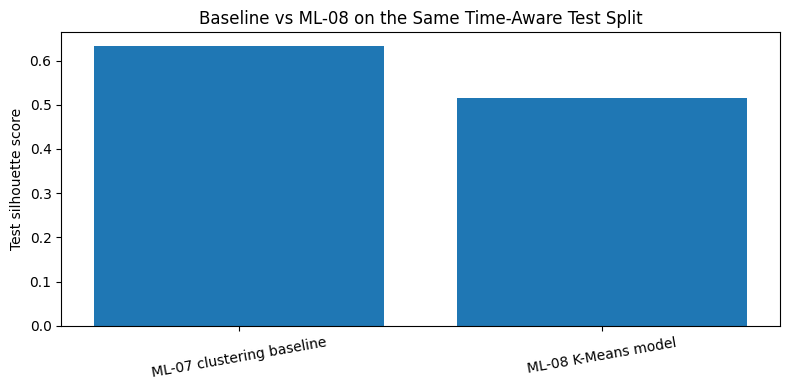

In [ ]:
plt.figure(figsize=(8, 4))

plt.bar(
    results_chart_df["method"],
    results_chart_df["test_silhouette"]
)

plt.ylabel("Test silhouette score")
plt.title("Baseline vs ML-08 on the Same Time-Aware Test Split")
plt.xticks(rotation=10)

plt.tight_layout()
plt.show()

### Paper artifact summary

The final paper will embed:

- the baseline-versus-model results table;
- the baseline cluster profile table;
- the cluster distribution chart;
- the ranked action playbook.

Together, these artifacts show both the measured comparison and how the observed clusters can support human review and prioritization.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.